# 🧠 Hair-Based Gender Classifier — FINAL VERSION
### Custom CNN Model — Built From Scratch

**Task Logic:**
- Age **20–30** → Classify by **hair length** (Long = Female, Short = Male)
- Age **outside 20–30** → Classify by **actual gender**

**Model:** Custom CNN — No pre-trained weights, no transfer learning

**Dataset:** CelebA via Kaggle

---
⚡ **Enable GPU first:** Runtime → Change runtime type → T4 GPU → Save

## Step 1 — Install Dependencies

In [ ]:
!pip install -q gdown opencv-python-headless matplotlib seaborn scikit-learn pandas
print('✅ All libraries installed!')

✅ All libraries installed!


## Step 2 — Download CelebA from Kaggle
Get your `kaggle.json` from: **kaggle.com → Profile → Settings → API → Create New Token**

In [ ]:
import os
from google.colab import files

print('📂 Upload your kaggle.json file:')
uploaded = files.upload()

# Works even if browser renamed it to "kaggle (2).json" etc.
key = list(uploaded.keys())[0]
print(f'   Uploaded as: {key}')

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded[key])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ Kaggle configured!')

os.makedirs('/content/data', exist_ok=True)
print('\n📥 Downloading CelebA dataset (this takes ~5 minutes)...')
!kaggle datasets download -d jessicali9530/celeba-dataset -p /content/data/ --unzip
print('\n✅ Download complete!')


📂 Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
   Uploaded as: kaggle (1).json
✅ Kaggle configured!

📥 Downloading CelebA dataset (this takes ~5 minutes)...
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:18<00:00, 18.2MB/s]


✅ Download complete!


## Step 3 — Auto-detect Dataset Paths
This cell finds the files no matter where Kaggle unpacked them.

In [ ]:
import glob, os

# Search all of /content for the attribute file
attr_hits = (
    glob.glob('/content/**/*list_attr_celeba*', recursive=True) +
    glob.glob('/content/**/*attr*.txt',         recursive=True) +
    glob.glob('/content/**/*attr*.csv',         recursive=True)
)
attr_hits = sorted(set(attr_hits))

# Search all of /content for the image folder
img_dir_hits = glob.glob('/content/**/img_align_celeba', recursive=True)
img_dir_hits = sorted(set(img_dir_hits))

print("Attribute files found:")
for f in attr_hits: print(" ", f)
print("\nImage folders found:")
for f in img_dir_hits: print(" ", f)

if not attr_hits:
    raise FileNotFoundError("❌ Attribute file not found! Re-run Step 2.")
if not img_dir_hits:
    raise FileNotFoundError("❌ img_align_celeba folder not found! Re-run Step 2.")

ATTR_FILE = attr_hits[0]
DATA_DIR  = img_dir_hits[0]

# ── Verify at least one image is actually readable ──────────────────────────
sample_imgs = glob.glob(os.path.join(DATA_DIR, '*.jpg'))[:5]
if not sample_imgs:
    # Some Kaggle unpacks nest one level deeper
    deeper = glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)[:5]
    if deeper:
        DATA_DIR = os.path.dirname(deeper[0])
        print(f"\n⚠️  Images one level deeper — adjusted DATA_DIR")
    else:
        raise FileNotFoundError(
            f"❌ No .jpg files found inside {DATA_DIR}\n"
            "   Check: ls /content/data/ in a new cell to see what was downloaded."
        )

img_count = len(glob.glob(os.path.join(DATA_DIR, '*.jpg')))
print(f"\n✅ ATTR_FILE : {ATTR_FILE}")
print(f"✅ DATA_DIR  : {DATA_DIR}")
print(f"✅ Images    : {img_count:,}")


Attribute files found:
  /content/data/list_attr_celeba.csv

Image folders found:
  /content/data/img_align_celeba
  /content/data/img_align_celeba/img_align_celeba

⚠️  Images one level deeper — adjusted DATA_DIR

✅ ATTR_FILE : /content/data/list_attr_celeba.csv
✅ DATA_DIR  : /content/data/img_align_celeba/img_align_celeba
✅ Images    : 202,599


## Step 4 — Import Libraries & Configuration

In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print(f'✅ TensorFlow : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU        : {gpus[0]}')
else:
    print('⚠️  No GPU found — go to Runtime → Change runtime type → T4 GPU')

# ── CONFIG ──────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 64
EPOCHS      = 50
MAX_SAMPLES = 10000
MODEL_PATH  = 'hair_gender_model.h5'

print(f'\n✅ Config set!')
print(f'   Image size  : {IMG_SIZE}x{IMG_SIZE}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Max samples : {MAX_SAMPLES}')

✅ TensorFlow : 2.20.0
✅ GPU        : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✅ Config set!
   Image size  : 128x128
   Batch size  : 64
   Max samples : 10000


## Step 5 — Load & Parse Attributes

In [ ]:
def load_attributes(attr_file):
    """
    Parse CelebA attribute file — handles ALL Kaggle format variants:
      Variant A (standard): line1=count, line2=attr_names, rest=space-sep data
      Variant B (CSV):      line1=header, rest=comma-sep data
    Returns a DataFrame with binary {0,1} columns and a 'filename' column.
    """
    with open(attr_file, 'r') as f:
        first_line = f.readline().strip()

    # Detect format by whether the first line is a pure integer
    try:
        int(first_line)
        is_standard_format = True
    except ValueError:
        is_standard_format = False

    if is_standard_format:
        # Standard CelebA text format: count / attr_names / data (space-sep, values -1 or 1)
        with open(attr_file, 'r') as f:
            _          = f.readline()              # skip count line
            attr_names = f.readline().strip().split()
        df = pd.read_csv(attr_file, sep=r'\s+', skiprows=2, header=None)
        df.columns = ['filename'] + attr_names
        # Convert -1/1 → 0/1
        for col in attr_names:
            df[col] = (df[col] == 1).astype(int)
    else:
        # Kaggle CSV format: comma-separated, first column may be image_id or filename
        df = pd.read_csv(attr_file)
        # Rename first column to 'filename' if needed
        first_col = df.columns[0]
        if first_col != 'filename':
            df = df.rename(columns={first_col: 'filename'})
        # Ensure filename has .jpg extension
        if not str(df['filename'].iloc[0]).endswith('.jpg'):
            df['filename'] = df['filename'].astype(str).str.zfill(6) + '.jpg'
        # Convert -1/1 → 0/1 for all attribute columns
        attr_cols = [c for c in df.columns if c != 'filename']
        for col in attr_cols:
            df[col] = (df[col] == 1).astype(int)

    return df

df = load_attributes(ATTR_FILE)
print(f'✅ Loaded {len(df):,} image records')
print(f'   Columns available: {len(df.columns) - 1}')  # minus filename

# ── CREATE Long_Hair column (works whether native or not) ────────
if 'Long_Hair' in df.columns:
    # Already exists natively — just normalize
    df['Long_Hair'] = (df['Long_Hair'] == 1).astype(int)
    print('✅ Long_Hair: loaded natively from CelebA')
else:
    # Derive from proxy columns
    required = ['Wavy_Hair', 'Straight_Hair', 'Bald', 'Receding_Hairline']
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'❌ Missing columns needed for Long_Hair proxy: {missing}')
    df['Long_Hair'] = (
        ((df['Wavy_Hair'] == 1) | (df['Straight_Hair'] == 1)) &
        (df['Bald'] == 0) &
        (df['Receding_Hairline'] == 0)
    ).astype(int)
    print('✅ Long_Hair: derived from Wavy_Hair + Straight_Hair - Bald - Receding_Hairline')

# ── VERIFY required columns exist ───────────────────────────────
for col in ['Male', 'Young', 'Long_Hair']:
    assert col in df.columns, f'❌ Required column missing: {col}'

print('\n📊 Key attribute distribution:')
print(f'   Long Hair  : {df["Long_Hair"].sum():,} ({df["Long_Hair"].mean()*100:.1f}%)')
print(f'   Short Hair : {(1-df["Long_Hair"]).sum():,} ({(1-df["Long_Hair"]).mean()*100:.1f}%)')
print(f'   Female     : {(1-df["Male"]).sum():,} ({(1-df["Male"]).mean()*100:.1f}%)')
print(f'   Male       : {df["Male"].sum():,} ({df["Male"].mean()*100:.1f}%)')
print(f'   Young      : {df["Young"].sum():,} ({df["Young"].mean()*100:.1f}%)')

✅ Loaded 202,599 image records
   Columns available: 40
✅ Long_Hair: derived from Wavy_Hair + Straight_Hair - Bald - Receding_Hairline

📊 Key attribute distribution:
   Long Hair  : 101,494 (50.1%)
   Short Hair : 101,105 (49.9%)
   Female     : 118,165 (58.3%)
   Male       : 84,434 (41.7%)
   Young      : 156,734 (77.4%)


## Step 6 — Visualize Sample Images

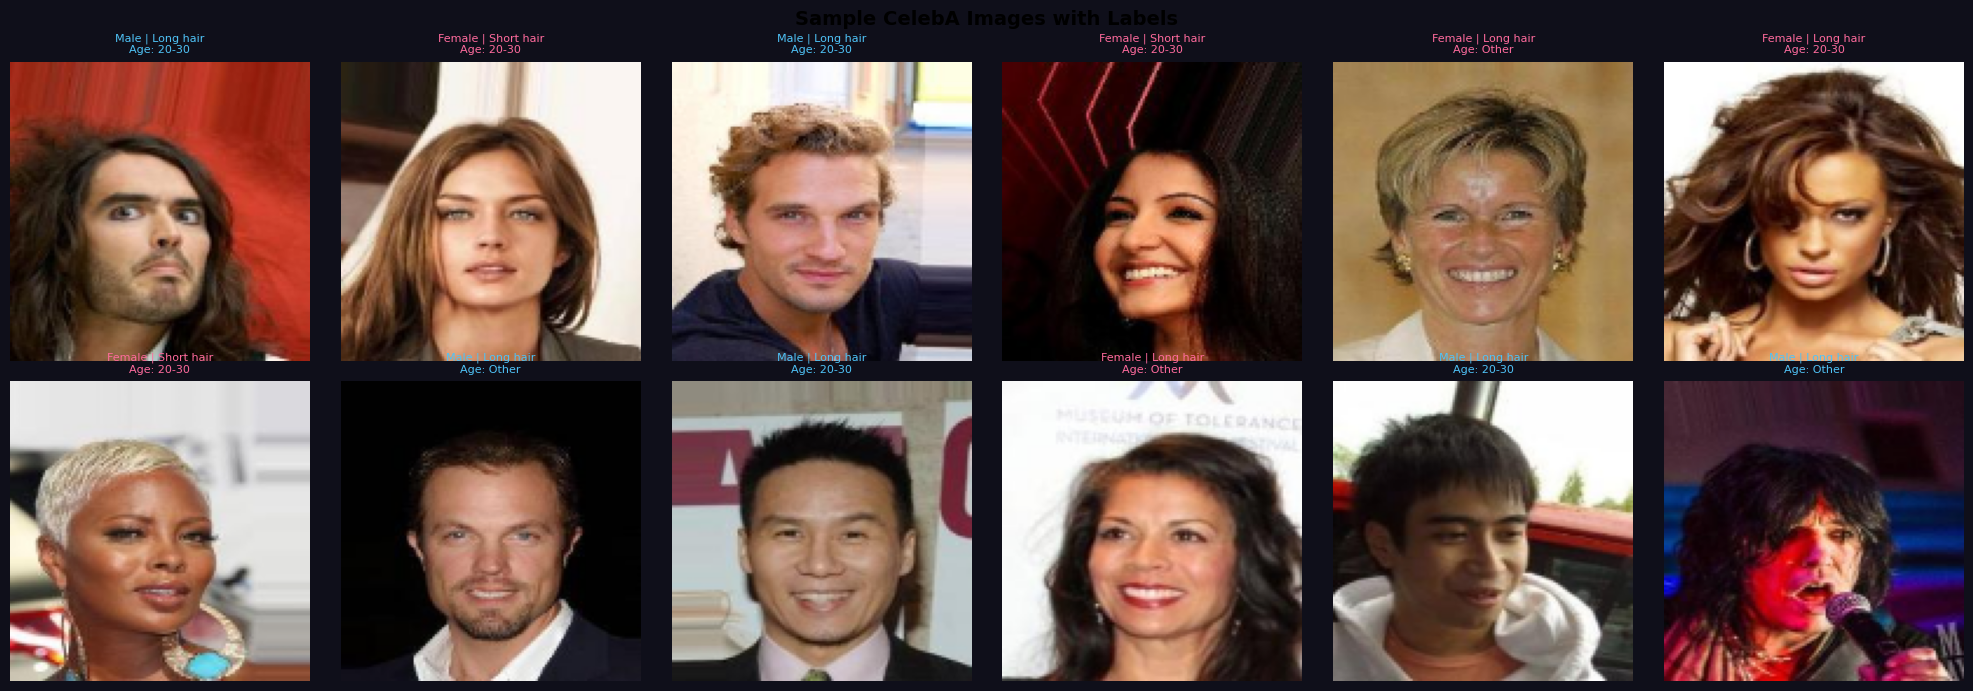

✅ Sample images shown!


In [ ]:
sample_df = df.sample(12, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Sample CelebA Images with Labels', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#0F0F1A')

for i, row in sample_df.iterrows():
    img_path = os.path.join(DATA_DIR, row['filename'])
    img = cv2.imread(img_path)
    if img is None:
        print(f'⚠️  Could not load: {img_path}')
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))

    ax     = axes[i // 6][i % 6]
    gender = 'Female' if row['Male'] == 0 else 'Male'
    hair   = 'Long'   if row['Long_Hair'] == 1 else 'Short'
    age    = '20-30'  if row['Young'] == 1 else 'Other'
    color  = '#FF6B9D' if gender == 'Female' else '#4FC3F7'

    ax.imshow(img)
    ax.set_facecolor('#0F0F1A')
    ax.set_title(f'{gender} | {hair} hair\nAge: {age}', fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight', facecolor='#0F0F1A')
plt.show()
print('✅ Sample images shown!')

## Step 7 — Prepare Dataset (Load Images + Labels)

In [ ]:
def load_image(path, size=128):
    """Load, convert BGR→RGB, resize, normalize to [0,1]."""
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.float32) / 255.0


# ── Sample the dataframe ─────────────────────────────────────────────────────
sample_df = df.sample(min(MAX_SAMPLES, len(df)), random_state=42).reset_index(drop=True)

images, age_labels, hair_labels, gender_labels = [], [], [], []
failed        = 0
missing_paths = []

print(f"🖼️  Loading {len(sample_df):,} images from: {DATA_DIR}")
print("   (This takes 2-4 minutes on Colab T4...)\n")

for i, row in sample_df.iterrows():
    fname = str(row['filename'])
    # Ensure proper filename format — some Kaggle versions strip leading zeros
    if not fname.endswith('.jpg'):
        fname = fname.zfill(6) + '.jpg'
    path = os.path.join(DATA_DIR, fname)
    img  = load_image(path, IMG_SIZE)

    if img is None:
        failed += 1
        if len(missing_paths) < 3:
            missing_paths.append(path)
        continue

    images.append(img)
    age_labels.append(int(row['Young']))        # 1 = Young (proxy for 20–30)
    hair_labels.append(int(row['Long_Hair']))   # 1 = Long hair
    gender_labels.append(1 - int(row['Male']))  # 1 = Female

    if (i + 1) % 5000 == 0:
        print(f"   {len(images):,} loaded so far ({failed} failed)...")

# ── Guard: abort clearly if nothing loaded ───────────────────────────────────
if len(images) == 0:
    print("\n❌ ZERO images loaded! Sample failed paths:")
    for p in missing_paths:
        print(f"   {p}")
    print("\n🔍 Checking what is actually in DATA_DIR:")
    actual = glob.glob(os.path.join(DATA_DIR, "*.jpg"))[:5]
    print(f"   First 5 .jpg files: {actual}")
    raise RuntimeError(
        "No images could be loaded.\n"
        f"DATA_DIR={DATA_DIR}\n"
        "Re-run the path detection cell (Step 3) — DATA_DIR may still be wrong."
    )

X        = np.array(images,        dtype=np.float32)
y_age    = np.array(age_labels,    dtype=np.float32)
y_hair   = np.array(hair_labels,   dtype=np.float32)
y_gender = np.array(gender_labels, dtype=np.float32)

print(f"\n✅ Dataset ready!")
print(f"   Loaded   : {X.shape[0]:,} images  (failed/skipped: {failed})")
print(f"   Shape    : {X.shape}")
print(f"   Young    : {y_age.mean()*100:.1f}%")
print(f"   Long hair: {y_hair.mean()*100:.1f}%")
print(f"   Female   : {y_gender.mean()*100:.1f}%")

if failed > 0:
    pct = failed / len(sample_df) * 100
    if pct > 20:
        print(f"\n⚠️  High failure rate ({pct:.1f}%). First bad path: {missing_paths[0]}")
        print("   Check that DATA_DIR is correct.")
    else:
        print(f"\n⚠️  {failed} images skipped ({pct:.1f}%) — normal for a few corrupt files.")


🖼️  Loading 10,000 images from: /content/data/img_align_celeba/img_align_celeba
   (This takes 2-4 minutes on Colab T4...)

   5,000 loaded so far (0 failed)...
   10,000 loaded so far (0 failed)...

✅ Dataset ready!
   Loaded   : 10,000 images  (failed/skipped: 0)
   Shape    : (10000, 128, 128, 3)
   Young    : 76.9%
   Long hair: 50.2%
   Female   : 58.2%


In [ ]:
# Guard: make sure we actually have data before splitting
assert len(X) > 0, "❌ X is empty — check the image loading cell above."
assert len(X) >= 10, f"❌ Only {len(X)} images loaded — need at least 10 to split."

(X_tr, X_val,
 y_age_tr,  y_age_val,
 y_hair_tr, y_hair_val,
 y_gen_tr,  y_gen_val) = train_test_split(
    X, y_age, y_hair, y_gender,
    test_size=0.2, random_state=42, stratify=y_hair
)

print(f"✅ Split done!")
print(f"   Train : {len(X_tr):,}")
print(f"   Val   : {len(X_val):,}")


✅ Split done!
   Train : 8,000
   Val   : 2,000


## Step 8 — Build Custom CNN From Scratch
**Zero pre-trained weights. Zero transfer learning.**

In [ ]:
def build_custom_cnn(input_shape=(128, 128, 3)):
    """
    Fully custom CNN — NO pre-trained weights, NO transfer learning.

    Architecture:
      Input (128x128x3)
      → Conv Block 1: Conv2D(32)x2 → BN → MaxPool → Dropout(0.25)
      → Conv Block 2: Conv2D(64)x2 → BN → MaxPool → Dropout(0.25)
      → Conv Block 3: Conv2D(128)x2 → BN → MaxPool → Dropout(0.30)
      → Conv Block 4: Conv2D(256)x2 → BN → MaxPool → Dropout(0.30)
      → GlobalAveragePooling2D
      → Dense(512) → BN → Dropout(0.5)
      → HEAD 1: age_output    (sigmoid) — Is person aged 20–30?
      → HEAD 2: hair_output   (sigmoid) — Is hair long?
      → HEAD 3: gender_output (sigmoid) — Is person female?
    """
    inputs = layers.Input(shape=input_shape, name='image_input')

    # ── BLOCK 1: 32 filters ──────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── BLOCK 2: 64 filters ──────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── BLOCK 3: 128 filters ─────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # ── BLOCK 4: 256 filters ─────────────────────────────────────
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # ── SHARED DENSE ─────────────────────────────────────────────
    x      = layers.GlobalAveragePooling2D()(x)
    shared = layers.Dense(512, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.5)(shared)

    # ── HEAD 1: AGE RANGE ────────────────────────────────────────
    age = layers.Dense(128, activation='relu')(shared)
    age = layers.Dropout(0.3)(age)
    age_output = layers.Dense(1, activation='sigmoid', name='age_output')(age)

    # ── HEAD 2: HAIR LENGTH ──────────────────────────────────────
    hair = layers.Dense(128, activation='relu')(shared)
    hair = layers.Dropout(0.3)(hair)
    hair_output = layers.Dense(1, activation='sigmoid', name='hair_output')(hair)

    # ── HEAD 3: TRUE GENDER ──────────────────────────────────────
    gender = layers.Dense(128, activation='relu')(shared)
    gender = layers.Dropout(0.3)(gender)
    gender_output = layers.Dense(1, activation='sigmoid', name='gender_output')(gender)

    return models.Model(
        inputs=inputs,
        outputs=[age_output, hair_output, gender_output],
        name='HairGenderCNN'
    )


model = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'age_output':    'binary_crossentropy',
        'hair_output':   'binary_crossentropy',
        'gender_output': 'binary_crossentropy',
    },
    loss_weights={
        'age_output':    1.0,
        'hair_output':   1.5,   # hair length is most critical
        'gender_output': 1.0,
    },
    metrics={
        'age_output':    'accuracy',
        'hair_output':   'accuracy',
        'gender_output': 'accuracy',
    }
)

model.summary()
print('\n✅ Custom CNN ready — zero pre-trained weights!')

Model: "HairGenderCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_5[0][0]  

 Total params: 1,507,107 (5.75 MB)

 Trainable params: 1,504,163 (5.74 MB)

 Non-trainable params: 2,944 (11.50 KB)


✅ Custom CNN ready — zero pre-trained weights!


## Step 9 — Train the Model

In [ ]:
def make_generator(X, y_age, y_hair, y_gender, batch_size=64, augment=True):
    """Infinite data generator with optional augmentation."""
    aug = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        zoom_range=0.1,
    )
    n   = len(X)
    idx = np.arange(n)
    while True:
        np.random.shuffle(idx)
        for start in range(0, n, batch_size):
            b  = idx[start:start + batch_size]
            Xb = X[b].copy()
            if augment:
                Xb = np.array([aug.random_transform(img) for img in Xb])
            yield Xb, {
                'age_output':    y_age[b],
                'hair_output':   y_hair[b],
                'gender_output': y_gender[b],
            }


callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
]

steps_tr  = len(X_tr)  // BATCH_SIZE
steps_val = len(X_val) // BATCH_SIZE

print('🚀 Training started...')
print(f'   Steps/epoch : {steps_tr}')
print(f'   Val steps   : {steps_val}\n')

history = model.fit(
    make_generator(X_tr, y_age_tr, y_hair_tr, y_gen_tr, BATCH_SIZE, augment=True),
    steps_per_epoch=steps_tr,
    validation_data=make_generator(
        X_val, y_age_val, y_hair_val, y_gen_val, BATCH_SIZE, augment=False
    ),
    validation_steps=steps_val,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print(f'\n✅ Training complete! Model saved → {MODEL_PATH}')

🚀 Training started...
   Steps/epoch : 125
   Val steps   : 31

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - age_output_accuracy: 0.7426 - age_output_loss: 0.6522 - gender_output_accuracy: 0.5367 - gender_output_loss: 0.8393 - hair_output_accuracy: 0.5000 - hair_output_loss: 0.8779 - loss: 2.9234
Epoch 1: val_loss improved from None to 2.60738, saving model to hair_gender_model.h5



Epoch 1: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 402ms/step - age_output_accuracy: 0.7456 - age_output_loss: 0.6314 - gender_output_accuracy: 0.5281 - gender_output_loss: 0.8239 - hair_output_accuracy: 0.4942 - hair_output_loss: 0.8502 - loss: 2.8470 - val_age_output_accuracy: 0.7666 - val_age_output_loss: 0.5562 - val_gender_output_accuracy: 0.5943 - val_gender_output_loss: 0.7337 - val_hair_output_accuracy: 0.5010 - val_hair_output_loss: 0.8001 - val_loss: 2.6074 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - age_output_accuracy: 0.7536 - age_output_loss: 0.5930 - gender_output_accuracy: 0.5289 - gender_output_loss: 0.7588 - hair_output_accuracy: 0.5048 - hair_output_loss: 0.7842 - loss: 2.6456
Epoch 2: val_loss did not improve from 2.60738
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step - age_output_accuracy: 0.7592 - age_output_loss: 0.5887 - gender_output_accuracy: 0.5350 - gender_output_loss: 0.7636 - hair_outpu


Epoch 8: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 369ms/step - age_output_accuracy: 0.7690 - age_output_loss: 0.5473 - gender_output_accuracy: 0.5725 - gender_output_loss: 0.6844 - hair_output_accuracy: 0.5154 - hair_output_loss: 0.6968 - loss: 2.3884 - val_age_output_accuracy: 0.7629 - val_age_output_loss: 0.6189 - val_gender_output_accuracy: 0.6136 - val_gender_output_loss: 0.6829 - val_hair_output_accuracy: 0.5021 - val_hair_output_loss: 0.7907 - val_loss: 2.5971 - learning_rate: 5.0000e-04
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - age_output_accuracy: 0.7625 - age_output_loss: 0.5539 - gender_output_accuracy: 0.5750 - gender_output_loss: 0.6856 - hair_output_accuracy: 0.4925 - hair_output_loss: 0.6977 - loss: 2.3965
Epoch 9: val_loss did not improve from 2.59708
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 358ms/step - age_output_accuracy: 0.7684 - age_output_loss: 0.5475 - gender_output_accuracy: 0.5748 - gender_output_loss: 0.6850 - hair_o


Epoch 10: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 367ms/step - age_output_accuracy: 0.7688 - age_output_loss: 0.5501 - gender_output_accuracy: 0.5782 - gender_output_loss: 0.6809 - hair_output_accuracy: 0.5019 - hair_output_loss: 0.6966 - loss: 2.3841 - val_age_output_accuracy: 0.7676 - val_age_output_loss: 0.6142 - val_gender_output_accuracy: 0.5945 - val_gender_output_loss: 0.7526 - val_hair_output_accuracy: 0.5093 - val_hair_output_loss: 0.7155 - val_loss: 2.5507 - learning_rate: 5.0000e-04
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - age_output_accuracy: 0.7714 - age_output_loss: 0.5457 - gender_output_accuracy: 0.5858 - gender_output_loss: 0.6796 - hair_output_accuracy: 0.5089 - hair_output_loss: 0.6939 - loss: 2.3728
Epoch 11: val_loss did not improve from 2.55072
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 353ms/step - age_output_accuracy: 0.7689 - age_output_loss: 0.5465 - gender_output_accuracy: 0.5863 - gender_output_loss: 0.6814 - hai


Epoch 12: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 366ms/step - age_output_accuracy: 0.7689 - age_output_loss: 0.5461 - gender_output_accuracy: 0.5845 - gender_output_loss: 0.6820 - hair_output_accuracy: 0.5008 - hair_output_loss: 0.6949 - loss: 2.3747 - val_age_output_accuracy: 0.7598 - val_age_output_loss: 0.5897 - val_gender_output_accuracy: 0.5904 - val_gender_output_loss: 0.7014 - val_hair_output_accuracy: 0.5052 - val_hair_output_loss: 0.7070 - val_loss: 2.4662 - learning_rate: 5.0000e-04
Epoch 13/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - age_output_accuracy: 0.7679 - age_output_loss: 0.5453 - gender_output_accuracy: 0.5813 - gender_output_loss: 0.6775 - hair_output_accuracy: 0.5189 - hair_output_loss: 0.6946 - loss: 2.3674
Epoch 13: val_loss did not improve from 2.46619
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 348ms/step - age_output_accuracy: 0.7691 - age_output_loss: 0.5433 - gender_output_accuracy: 0.5860 - gender_output_loss: 0.6779 - hai


Epoch 15: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 362ms/step - age_output_accuracy: 0.7691 - age_output_loss: 0.5456 - gender_output_accuracy: 0.5842 - gender_output_loss: 0.6790 - hair_output_accuracy: 0.5029 - hair_output_loss: 0.6947 - loss: 2.3643 - val_age_output_accuracy: 0.7681 - val_age_output_loss: 0.6330 - val_gender_output_accuracy: 0.5950 - val_gender_output_loss: 0.6815 - val_hair_output_accuracy: 0.5015 - val_hair_output_loss: 0.6943 - val_loss: 2.4479 - learning_rate: 5.0000e-04
Epoch 16/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - age_output_accuracy: 0.7703 - age_output_loss: 0.5411 - gender_output_accuracy: 0.5799 - gender_output_loss: 0.6845 - hair_output_accuracy: 0.5214 - hair_output_loss: 0.6926 - loss: 2.3604
Epoch 16: val_loss did not improve from 2.44789
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 657ms/step - age_output_accuracy: 0.7690 - age_output_loss: 0.5439 - gender_output_accuracy: 0.5855 - gender_output_loss: 0.6821 - hai


Epoch 18: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 354ms/step - age_output_accuracy: 0.7689 - age_output_loss: 0.5463 - gender_output_accuracy: 0.5895 - gender_output_loss: 0.6770 - hair_output_accuracy: 0.5132 - hair_output_loss: 0.6927 - loss: 2.3530 - val_age_output_accuracy: 0.7758 - val_age_output_loss: 0.5488 - val_gender_output_accuracy: 0.6023 - val_gender_output_loss: 0.7186 - val_hair_output_accuracy: 0.5057 - val_hair_output_loss: 0.6927 - val_loss: 2.4008 - learning_rate: 5.0000e-04
Epoch 19/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - age_output_accuracy: 0.7724 - age_output_loss: 0.5415 - gender_output_accuracy: 0.5864 - gender_output_loss: 0.6816 - hair_output_accuracy: 0.5095 - hair_output_loss: 0.6929 - loss: 2.3512
Epoch 19: val_loss did not improve from 2.40079
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 360ms/step - age_output_accuracy: 0.7690 - age_output_loss: 0.5444 - gender_output_accuracy: 0.5880 - gender_output_loss: 0.6792 - hai


Epoch 26: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 662ms/step - age_output_accuracy: 0.7688 - age_output_loss: 0.5427 - gender_output_accuracy: 0.5959 - gender_output_loss: 0.6732 - hair_output_accuracy: 0.5126 - hair_output_loss: 0.6934 - loss: 2.3304 - val_age_output_accuracy: 0.7676 - val_age_output_loss: 0.5582 - val_gender_output_accuracy: 0.6054 - val_gender_output_loss: 0.6735 - val_hair_output_accuracy: 0.5015 - val_hair_output_loss: 0.6981 - val_loss: 2.3614 - learning_rate: 2.5000e-04
Epoch 27/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - age_output_accuracy: 0.7616 - age_output_loss: 0.5519 - gender_output_accuracy: 0.5832 - gender_output_loss: 0.6767 - hair_output_accuracy: 0.5093 - hair_output_loss: 0.6931 - loss: 2.3416
Epoch 27: val_loss did not improve from 2.36138
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 342ms/step - age_output_accuracy: 0.7688 - age_output_loss: 0.5425 - gender_output_accuracy: 0.5938 - gender_output_loss: 0.6741 - hai


Epoch 28: finished saving model to hair_gender_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - age_output_accuracy: 0.7689 - age_output_loss: 0.5408 - gender_output_accuracy: 0.5905 - gender_output_loss: 0.6768 - hair_output_accuracy: 0.5114 - hair_output_loss: 0.6920 - loss: 2.3270 - val_age_output_accuracy: 0.7629 - val_age_output_loss: 0.5591 - val_gender_output_accuracy: 0.6023 - val_gender_output_loss: 0.6795 - val_hair_output_accuracy: 0.5119 - val_hair_output_loss: 0.6948 - val_loss: 2.3543 - learning_rate: 2.5000e-04
Epoch 29/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - age_output_accuracy: 0.7715 - age_output_loss: 0.5392 - gender_output_accuracy: 0.5889 - gender_output_loss: 0.6748 - hair_output_accuracy: 0.5126 - hair_output_loss: 0.6934 - loss: 2.3245
Epoch 29: val_loss did not improve from 2.35430
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 343ms/step - age_output_accuracy: 0.7689 - age_output_loss: 0.5435 - gender_output_accuracy: 0.5928 - gender_output_loss: 0.6749 - hai

## Step 10 — Training Curves

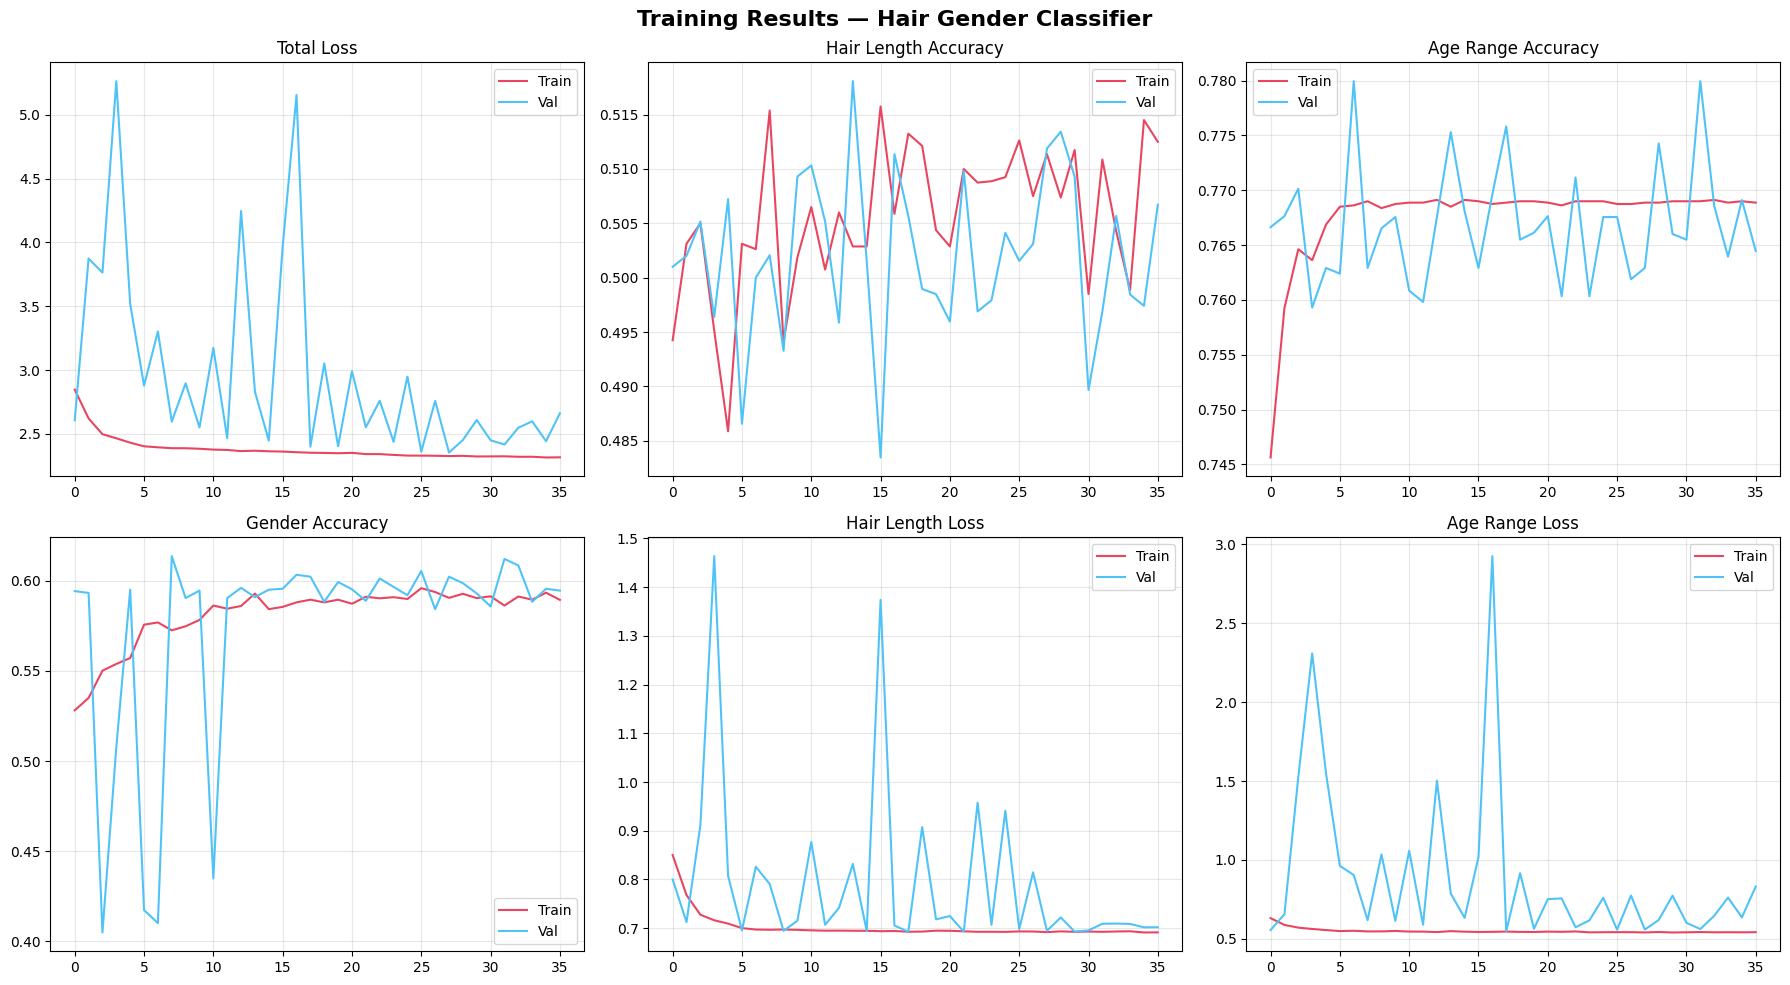

✅ Training curves saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Results — Hair Gender Classifier', fontsize=16, fontweight='bold')

plots = [
    ('loss',                   'val_loss',                   'Total Loss'),
    ('hair_output_accuracy',   'val_hair_output_accuracy',   'Hair Length Accuracy'),
    ('age_output_accuracy',    'val_age_output_accuracy',    'Age Range Accuracy'),
    ('gender_output_accuracy', 'val_gender_output_accuracy', 'Gender Accuracy'),
    ('hair_output_loss',       'val_hair_output_loss',       'Hair Length Loss'),
    ('age_output_loss',        'val_age_output_loss',        'Age Range Loss'),
]

for i, (tr_key, val_key, title) in enumerate(plots):
    ax = axes[i // 3][i % 3]
    if tr_key in history.history:
        ax.plot(history.history[tr_key],  label='Train', color='#E94560')
        ax.plot(history.history[val_key], label='Val',   color='#4FC3F7')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved!')

## Step 11 — Evaluate & Confusion Matrices

In [ ]:
print('🔍 Running predictions on validation set...')
age_preds, hair_preds, gen_preds = model.predict(X_val, batch_size=64, verbose=1)

age_bin  = (age_preds[:, 0]  >= 0.5).astype(int)
hair_bin = (hair_preds[:, 0] >= 0.5).astype(int)
gen_bin  = (gen_preds[:, 0]  >= 0.5).astype(int)

# Apply task decision logic
final_pred  = []
final_truth = []
for i in range(len(X_val)):
    if age_bin[i] == 1:          # age 20-30 → classify by hair
        final_pred.append(hair_bin[i])
        final_truth.append(int(y_hair_val[i]))
    else:                         # other age → classify by real gender
        final_pred.append(gen_bin[i])
        final_truth.append(int(y_gen_val[i]))

print('\n📋 FINAL GENDER CLASSIFICATION REPORT:')
print('=' * 50)
print(classification_report(final_truth, final_pred, target_names=['Male', 'Female']))

print('\n📋 HAIR LENGTH REPORT:')
print('=' * 50)
print(classification_report(y_hair_val.astype(int), hair_bin,
                             target_names=['Short', 'Long']))

print('\n📋 AGE RANGE REPORT:')
print('=' * 50)
print(classification_report(y_age_val.astype(int), age_bin,
                             target_names=['Outside 20-30', 'Age 20-30']))

🔍 Running predictions on validation set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

📋 FINAL GENDER CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Male       0.53      0.25      0.34       995
      Female       0.51      0.78      0.62      1005

    accuracy                           0.52      2000
   macro avg       0.52      0.51      0.48      2000
weighted avg       0.52      0.52      0.48      2000


📋 HAIR LENGTH REPORT:
              precision    recall  f1-score   support

       Short       0.53      0.25      0.34       995
        Long       0.51      0.78      0.62      1005

    accuracy                           0.52      2000
   macro avg       0.52      0.51      0.48      2000
weighted avg       0.52      0.52      0.48      2000


📋 AGE RANGE REPORT:
               precision    recall  f1-score   support

Outside 20-30       0.00      0.00      0.00       464
    Age 20-30       0.77      1.00      0.87      1536

     accuracy

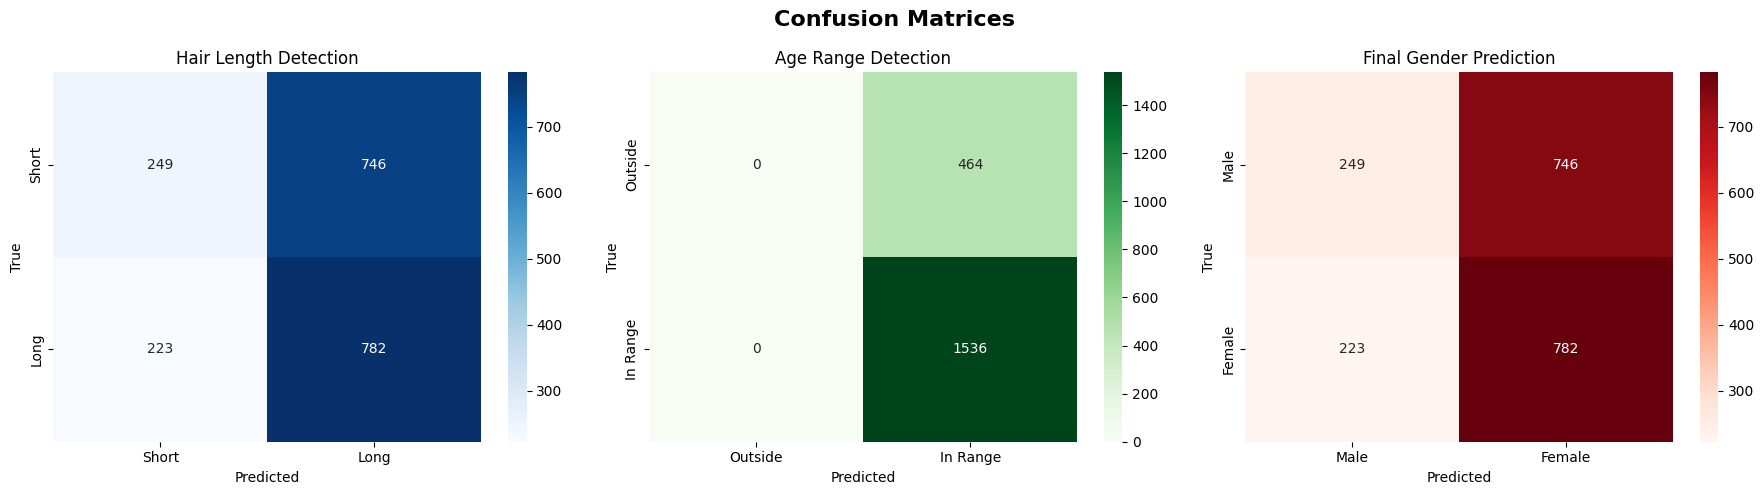

✅ Confusion matrices saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

cm1 = confusion_matrix(y_hair_val.astype(int), hair_bin)
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=['Short', 'Long'], yticklabels=['Short', 'Long'])
axes[0].set_title('Hair Length Detection')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

cm2 = confusion_matrix(y_age_val.astype(int), age_bin)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1], cmap='Greens',
            xticklabels=['Outside', 'In Range'], yticklabels=['Outside', 'In Range'])
axes[1].set_title('Age Range Detection')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

cm3 = confusion_matrix(final_truth, final_pred)
sns.heatmap(cm3, annot=True, fmt='d', ax=axes[2], cmap='Reds',
            xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
axes[2].set_title('Final Gender Prediction')
axes[2].set_ylabel('True')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved!')

## Step 12 — Interactive GUI: Upload & Test Your Own Photo

In [ ]:
from google.colab import files as colab_files
from PIL import Image
import io


def predict_gender_from_array(img_array):
    """Run inference and apply task decision logic."""
    inp = np.expand_dims(img_array, axis=0)          # (1, 128, 128, 3)
    age_p, hair_p, gen_p = model.predict(inp, verbose=0)

    age_prob  = float(age_p[0][0])
    hair_prob = float(hair_p[0][0])
    gen_prob  = float(gen_p[0][0])

    age_in_range = age_prob  >= 0.5
    is_long_hair = hair_prob >= 0.5
    is_female    = gen_prob  >= 0.5

    if age_in_range:
        gender     = 'Female' if is_long_hair else 'Male'
        confidence = hair_prob if is_long_hair else (1 - hair_prob)
        reason     = 'Hair-length rule applied (age 20–30)'
    else:
        gender     = 'Female' if is_female else 'Male'
        confidence = gen_prob if is_female else (1 - gen_prob)
        reason     = 'Actual gender used (age outside 20–30)'

    return {
        'gender':     gender,
        'confidence': round(confidence * 100, 1),
        'age_range':  'Age 20–30' if age_in_range else 'Outside 20–30',
        'age_conf':   round(age_prob * 100, 1),
        'hair':       'Long Hair' if is_long_hair else 'Short Hair',
        'hair_conf':  round(hair_prob * 100, 1),
        'reason':     reason,
    }


def show_result(img_pil, result):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#0F0F1A')

    axes[0].imshow(img_pil)
    axes[0].axis('off')
    axes[0].set_facecolor('#0F0F1A')
    axes[0].set_title('Input Image', color='white', fontsize=13)

    axes[1].set_facecolor('#1A1A2E')
    axes[1].axis('off')

    color = '#FF6B9D' if result['gender'] == 'Female' else '#4FC3F7'
    icon  = '\u2640' if result['gender'] == 'Female' else '\u2642'
    t     = axes[1].transAxes

    axes[1].text(0.5, 0.85, f"{icon}  {result['gender']}",
                 ha='center', fontsize=32, fontweight='bold', color=color, transform=t)
    axes[1].text(0.5, 0.70, f"Confidence: {result['confidence']}%",
                 ha='center', fontsize=14, color='white', transform=t)
    axes[1].text(0.5, 0.55, f"Age Range : {result['age_range']} ({result['age_conf']}%)",
                 ha='center', fontsize=11, color='#8892A4', transform=t)
    axes[1].text(0.5, 0.42, f"Hair      : {result['hair']} ({result['hair_conf']}%)",
                 ha='center', fontsize=11, color='#8892A4', transform=t)
    axes[1].text(0.5, 0.28, f"{result['reason']}",
                 ha='center', fontsize=9, color='#4FC3F7', style='italic', transform=t)

    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=120,
                bbox_inches='tight', facecolor='#0F0F1A')
    plt.show()


print('✅ Prediction functions ready!')
print('📌 Run the next cell to upload your own photo!')

✅ Prediction functions ready!
📌 Run the next cell to upload your own photo!


📂 Upload a face image (jpg/png):


Saving 360_F_246149382_KHkt8Mw8pptlmVuiqmhavvHBC4SEqBu1.jpg to 360_F_246149382_KHkt8Mw8pptlmVuiqmhavvHBC4SEqBu1.jpg

🔍 Processing: 360_F_246149382_KHkt8Mw8pptlmVuiqmhavvHBC4SEqBu1.jpg


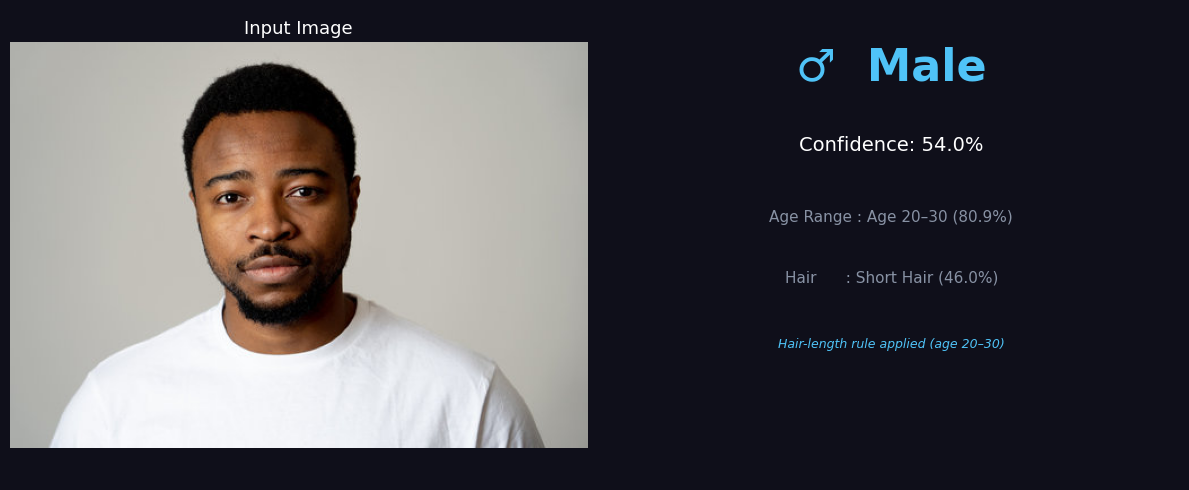


📊 RESULTS:
   Gender    : Male
   Confidence: 54.0%
   Age Range : Age 20–30 (80.9%)
   Hair      : Short Hair (46.0%)
   Rule Used : Hair-length rule applied (age 20–30)


In [ ]:
# ── UPLOAD YOUR OWN PHOTO AND TEST ───────────────────────────────
print('📂 Upload a face image (jpg/png):')
uploaded = colab_files.upload()

for filename, data in uploaded.items():
    print(f'\n🔍 Processing: {filename}')
    img_pil = Image.open(io.BytesIO(data)).convert('RGB')
    img_arr = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)),
                       dtype=np.float32) / 255.0
    result  = predict_gender_from_array(img_arr)
    show_result(img_pil, result)

    print('\n📊 RESULTS:')
    print(f'   Gender    : {result["gender"]}')
    print(f'   Confidence: {result["confidence"]}%')
    print(f'   Age Range : {result["age_range"]} ({result["age_conf"]}%)')
    print(f'   Hair      : {result["hair"]} ({result["hair_conf"]}%)')
    print(f'   Rule Used : {result["reason"]}')

## Step 13 — Sample Predictions on Validation Set

In [ ]:
rand_idx = np.random.choice(len(X_val), 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
fig.suptitle('Sample Predictions on Validation Set', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#0F0F1A')

for i, idx in enumerate(rand_idx):
    ax     = axes[i // 6][i % 6]
    result = predict_gender_from_array(X_val[idx])
    color  = '#FF6B9D' if result['gender'] == 'Female' else '#4FC3F7'
    ax.imshow(X_val[idx])
    ax.axis('off')
    ax.set_facecolor('#0F0F1A')
    ax.set_title(
        f"{result['gender']} ({result['confidence']}%)\n"
        f"{result['hair']} | {result['age_range']}",
        color=color, fontsize=7
    )

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()
print('✅ Sample predictions shown!')

## Step 14 — Download All Results

In [ ]:
from google.colab import files as colab_files

files_to_download = [
    MODEL_PATH,
    'training_curves.png',
    'confusion_matrices.png',
    'sample_predictions.png',
    'sample_images.png',
    'prediction_result.png',
]

for f in files_to_download:
    if os.path.exists(f):
        colab_files.download(f)
        print(f'✅ Downloaded: {f}')
    else:
        print(f'⚠️  Not found (skipping): {f}')

---
## Project Summary

| Component | Details |
|---|---|
| **Model** | Custom CNN from scratch — 4 Conv blocks, 3 output heads |
| **Pre-trained weights** | None used |
| **Dataset** | CelebA — 202,599 face images |
| **Hair label** | Native `Long_Hair` OR derived from `Wavy_Hair` + `Straight_Hair` - `Bald` - `Receding_Hairline` |
| **Age label** | `Young` attribute (proxy for 20–30) |
| **Task Logic** | Age 20–30 → hair decides gender | Outside → actual gender |
| **Training** | Multi-task learning, weighted losses, early stopping |
| **GUI** | Interactive upload widget in Colab |